In [15]:
from pyscf import gto, dft
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import numpy as np
import os
import pandas as pd


# Statistical Analysis of Molecular Dynamics Near a Zn Active Site in Solvent

This project investigates how stochastic solvent configurations influence the electronic and geometric properties of a Zn active site model.

Instead of treating the system as a single optimized structure, we generate an ensemble of configurations by randomly placing a water molecule near the Zn center. Each configuration represents a sample from a distribution of solvent environments.

We then compute observables such as total energy, HOMO–LUMO gap, and Zn–O(water) distance, and analyze their statistical behavior using methods from computational statistics.

**Key Idea:** Molecular systems at finite temperature are inherently stochastic. Therefore, analyzing a distribution of configurations provides more insight than analyzing a single deterministic structure.

# User Config of the system and sampling parameters

In [16]:
ROOT_DIR = os.path.dirname(os.path.abspath("__file__"))

USE_XYZ_FILE = False   # True = use .xyz file, False = use Zn-only

XYZ_FILE = "active_site_202604222145.xyz"

ZN_ONLY_ATOMS = [
    ("Zn", np.array([0.0, 0.0, 0.0]))
]

N_SAMPLES = 50          # start small first; increase later
BASIS = "lanl2dz"
XC = "HF"

CHARGE = 0              # change if needed
SPIN = 0                # 2S = Nalpha - Nbeta

R_MIN = 2.0             # minimum Zn-O(water) distance in Angstrom
R_MAX = 5.0             # maximum Zn-O(water) distance in Angstrom

OUTPUT_DIR = Path("water_sampling_results")
OUTPUT_DIR.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Read the base XYZ file to get the atomic positions and identify the Zn atom's position.
This will be used as a reference point for placing the water molecule.

In [17]:
# =========================
# READ BASE XYZ FILE
# =========================

def read_xyz(filename):
    atoms = []

    with open(filename, "r") as f:
        lines = f.readlines()

    for line in lines[2:]:  # skip XYZ header
        parts = line.split()
        if len(parts) == 4:
            elem = parts[0]
            coord = np.array([float(parts[1]), float(parts[2]), float(parts[3])])
            atoms.append((elem, coord))

    return atoms


def find_zn_position(atoms):
    for elem, coord in atoms:
        if elem.lower() == "zn":
            return coord

    raise ValueError("No Zn atom found in the XYZ file.")



# Create the water molecule with realistic geometry
Using the bond length of O-H = 0.96 Å and the angle of H-O-H = 104.5 degrees, we can construct the coordinates of the water molecule. The oxygen atom will be placed at the origin, and the two hydrogen atoms will be positioned according to the specified geometry.


In [18]:
def create_water():
    """
    Creates one water molecule with realistic geometry.
    O-H bond length ~0.96 Angstrom
    H-O-H angle ~104.5 degrees
    """
    OH = 0.96
    angle = np.deg2rad(104.5)

    O = np.array([0.0, 0.0, 0.0])
    H1 = np.array([OH, 0.0, 0.0])
    H2 = np.array([
        OH * np.cos(angle),
        OH * np.sin(angle),
        0.0
    ])

    return np.array([O, H1, H2])

# Random Elements built in to build the dataset
Place water molecule randomly around the Zn atom within the specified distance range. This involves generating random orientations and positions for the water molecule.
- rotation matrix to orient the water molecule randomly in 3D space
- Samples a random point in a spherical shell around Zn.

In [19]:
def random_rotation_matrix():
    """
    Generates a random 3D rotation matrix using a random quaternion.
    """
    u1, u2, u3 = np.random.rand(3)

    q1 = np.sqrt(1 - u1) * np.sin(2 * np.pi * u2)
    q2 = np.sqrt(1 - u1) * np.cos(2 * np.pi * u2)
    q3 = np.sqrt(u1) * np.sin(2 * np.pi * u3)
    q4 = np.sqrt(u1) * np.cos(2 * np.pi * u3)

    R = np.array([
        [1 - 2 * (q3**2 + q4**2), 2 * (q2*q3 - q1*q4),     2 * (q2*q4 + q1*q3)],
        [2 * (q2*q3 + q1*q4),     1 - 2 * (q2**2 + q4**2), 2 * (q3*q4 - q1*q2)],
        [2 * (q2*q4 - q1*q3),     2 * (q3*q4 + q1*q2),     1 - 2 * (q2**2 + q3**2)]
    ])

    return R


def random_position_around(center, r_min=2.0, r_max=5.0):
    """
    Samples a random point in a spherical shell around Zn.
    """
    r = np.random.uniform(r_min, r_max)
    theta = np.random.uniform(0, np.pi)
    phi = np.random.uniform(0, 2 * np.pi)

    x = center[0] + r * np.sin(theta) * np.cos(phi)
    y = center[1] + r * np.sin(theta) * np.sin(phi)
    z = center[2] + r * np.cos(theta)

    return np.array([x, y, z])

## Apply the random rotation and translation to place the water molecule near Zn.
The oxygen atom of the water will be placed at the sampled position

In [20]:
def place_water_near_zn(zn_position, r_min=2.0, r_max=5.0):
    """
    Places one randomly oriented water molecule near Zn.
    The oxygen atom is placed at a sampled distance from Zn.
    """
    water = create_water()

    R = random_rotation_matrix()
    water_rotated = water @ R.T

    oxygen_target = random_position_around(
        zn_position,
        r_min=r_min,
        r_max=r_max
    )

    shift = oxygen_target - water_rotated[0]
    water_final = water_rotated + shift

    return water_final

# Build the geometry string for PySCF and save the XYZ files for each sample.

In [21]:
def build_atom_string(base_atoms, water_coords):
    atom_string = ""

    for elem, coord in base_atoms:
        atom_string += f"{elem} {coord[0]:.8f} {coord[1]:.8f} {coord[2]:.8f}\n"

    atom_string += f"O {water_coords[0,0]:.8f} {water_coords[0,1]:.8f} {water_coords[0,2]:.8f}\n"
    atom_string += f"H {water_coords[1,0]:.8f} {water_coords[1,1]:.8f} {water_coords[1,2]:.8f}\n"
    atom_string += f"H {water_coords[2,0]:.8f} {water_coords[2,1]:.8f} {water_coords[2,2]:.8f}\n"

    return atom_string


def save_xyz(filename, base_atoms, water_coords):
    total_atoms = len(base_atoms) + 3

    with open(filename, "w") as f:
        f.write(f"{total_atoms}\n")
        f.write("Active site with randomly sampled water molecule\n")

        for elem, coord in base_atoms:
            f.write(f"{elem} {coord[0]:.8f} {coord[1]:.8f} {coord[2]:.8f}\n")

        f.write(f"O {water_coords[0,0]:.8f} {water_coords[0,1]:.8f} {water_coords[0,2]:.8f}\n")
        f.write(f"H {water_coords[1,0]:.8f} {water_coords[1,1]:.8f} {water_coords[1,2]:.8f}\n")
        f.write(f"H {water_coords[2,0]:.8f} {water_coords[2,1]:.8f} {water_coords[2,2]:.8f}\n")


# Run the PySCF calculations for each sampled structure and collect the results.

In [22]:
# =========================
# RUN PYSCF
# =========================

def run_pyscf(atom_string):
    mol = gto.M(
        atom=atom_string,
        basis=BASIS,
        unit="Ang",
        charge=CHARGE,
        spin=SPIN
    )

    mf = dft.UKS(mol)
    mf.xc = XC

    energy = mf.kernel()

    mo_energy = mf.mo_energy

    # For UKS, mo_energy has alpha and beta arrays.
    alpha_energies = mo_energy[0]
    alpha_occ = mf.mo_occ[0]

    occupied = alpha_energies[alpha_occ > 0]
    virtual = alpha_energies[alpha_occ == 0]

    homo = occupied[-1]
    lumo = virtual[0]
    gap = lumo - homo

    return energy, homo, lumo, gap, mf.converged


# Main sampling loop
Sample random water configuration and compute the properties to build a statistical distribution

In [23]:
# =========================
# MAIN SAMPLING LOOP
# =========================

if USE_XYZ_FILE:
    print("Using XYZ file input")
    base_atoms = read_xyz(XYZ_FILE)
else:
    print("Using Zn-only test system")
    base_atoms = ZN_ONLY_ATOMS

zn_position = find_zn_position(base_atoms)

print("Zn position:", zn_position)

results = []

xyz_output_dir = OUTPUT_DIR / f"xyz_samples_{timestamp}"
xyz_output_dir.mkdir(exist_ok=True)

for i in range(N_SAMPLES):
    print(f"\nRunning sample {i + 1}/{N_SAMPLES}")

    water_coords = place_water_near_zn(
        zn_position,
        r_min=R_MIN,
        r_max=R_MAX
    )

    zn_o_distance = np.linalg.norm(water_coords[0] - zn_position)

    atom_string = build_atom_string(base_atoms, water_coords)

    sample_xyz_file = xyz_output_dir / f"sample_{i:04d}.xyz"
    save_xyz(sample_xyz_file, base_atoms, water_coords)

    try:
        energy, homo, lumo, gap, converged = run_pyscf(atom_string)

        results.append({
            "sample": i,
            "zn_o_water_distance_A": zn_o_distance,
            "total_energy_hartree": energy,
            "homo_hartree": homo,
            "lumo_hartree": lumo,
            "gap_hartree": gap,
            "converged": converged,
            "xyz_file": str(sample_xyz_file)
        })

        print(f"Energy: {energy:.8f} Ha")
        print(f"Zn-O distance: {zn_o_distance:.3f} A")
        print(f"Gap: {gap:.6f} Ha")
        print(f"Converged: {converged}")

    except Exception as e:
        print(f"Sample {i} failed: {e}")

        results.append({
            "sample": i,
            "zn_o_water_distance_A": zn_o_distance,
            "total_energy_hartree": np.nan,
            "homo_hartree": np.nan,
            "lumo_hartree": np.nan,
            "gap_hartree": np.nan,
            "converged": False,
            "xyz_file": str(sample_xyz_file)
        })

# =========================
# SAVE RESULTS
# =========================

df = pd.DataFrame(results)

csv_file = OUTPUT_DIR / f"water_sampling_results_{timestamp}.csv"
df.to_csv(csv_file, index=False)

print("\nDone!")
print(f"Results saved to: {csv_file}")
print(f"XYZ samples saved to: {xyz_output_dir}")

Using Zn-only test system
Zn position: [0. 0. 0.]

Running sample 1/50
converged SCF energy = -529.874466443813  <S^2> = 3.8191672e-10  2S+1 = 1
Energy: -529.87446644 Ha
Zn-O distance: 4.974 A
Gap: 0.541487 Ha
Converged: True

Running sample 2/50
converged SCF energy = -529.893865093088  <S^2> = 3.3797676e-10  2S+1 = 1
Energy: -529.89386509 Ha
Zn-O distance: 4.812 A
Gap: 0.541287 Ha
Converged: True

Running sample 3/50
converged SCF energy = -530.122917501388  <S^2> = 6.8361317e-11  2S+1 = 1
Energy: -530.12291750 Ha
Zn-O distance: 4.663 A
Gap: 0.535447 Ha
Converged: True

Running sample 4/50
converged SCF energy = -531.723085954481  <S^2> = 3.2564174e-11  2S+1 = 1
Energy: -531.72308595 Ha
Zn-O distance: 2.243 A
Gap: 0.703021 Ha
Converged: True

Running sample 5/50
converged SCF energy = -530.255406078715  <S^2> = 7.2617468e-12  2S+1 = 1
Energy: -530.25540608 Ha
Zn-O distance: 4.114 A
Gap: 0.539023 Ha
Converged: True

Running sample 6/50
converged SCF energy = -531.030410665959  <S^2> =

# Main Statistical Analysis
- Zn-O water distance distribution
- total energy distribution
- HOMO-LUMO gap distribution
- Distance vs energy
- Distance vs HOMO-LUMO Gap
- Energy vs gap
- bootstrapping confidence intervals
- bootstrap histogram: energy mean
- bootstrap histogram: HOMO-LUMO Gap Mean

## Load the generated csv files
- load the generated results from pyscf calculation above in the csv file
- create an output folder for these statistical analysis plots

In [27]:
csv_file = "water_sampling_results/water_sampling_results_2026-04-30_23-26-21.csv"

df = pd.read_csv(csv_file)

# Keep only successful/converged samples
df_clean = df.dropna(subset=[
    "zn_o_water_distance_A",
    "total_energy_hartree",
    "homo_hartree",
    "lumo_hartree",
    "gap_hartree"
])

# Optional: only converged calculations
df_clean = df

print(df_clean.head())
print(df_clean.describe())

# =========================
# OUTPUT FOLDER
# =========================

plot_dir = Path("water_sampling_plots")
plot_dir.mkdir(exist_ok=True)

   sample  zn_o_water_distance_A  total_energy_hartree  homo_hartree  \
0       0               4.973668           -529.874466     -0.508870   
1       1               4.812488           -529.893865     -0.509744   
2       2               4.662885           -530.122918     -0.510802   
3       3               2.242633           -531.723086     -0.670494   
4       4               4.114268           -530.255406     -0.516673   

   lumo_hartree  gap_hartree  converged  \
0      0.032618     0.541487       True   
1      0.031543     0.541287       True   
2      0.024645     0.535447       True   
3      0.032527     0.703021       True   
4      0.022349     0.539023       True   

                                            xyz_file  
0  water_sampling_results/xyz_samples_2026-04-30_...  
1  water_sampling_results/xyz_samples_2026-04-30_...  
2  water_sampling_results/xyz_samples_2026-04-30_...  
3  water_sampling_results/xyz_samples_2026-04-30_...  
4  water_sampling_results/xyz_sam

## Zn-O Water Distance Distribution


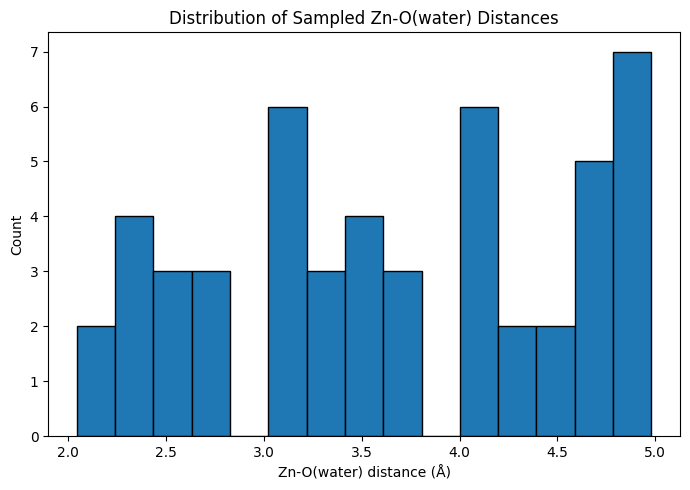

In [28]:
plt.figure(figsize=(7, 5))
plt.hist(df_clean["zn_o_water_distance_A"], bins=15, edgecolor="black")
plt.xlabel("Zn-O(water) distance (Å)")
plt.ylabel("Count")
plt.title("Distribution of Sampled Zn-O(water) Distances")
plt.tight_layout()
plt.savefig(plot_dir / "distance_distribution.png", dpi=300)
plt.show()

## Total Energy Distribution

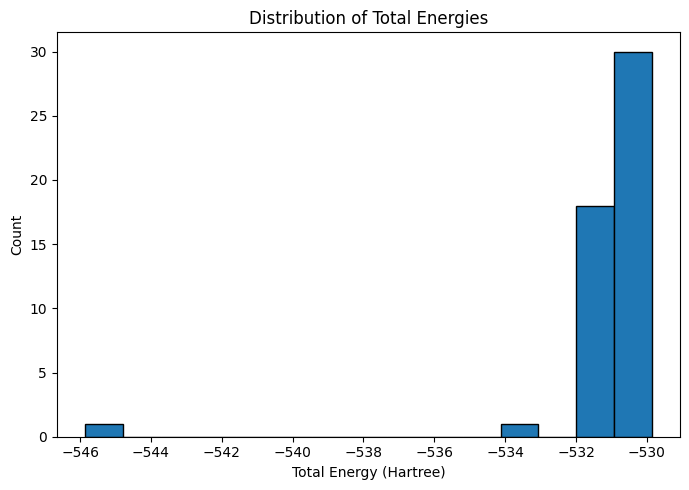

In [29]:
# =========================
# 2. TOTAL ENERGY DISTRIBUTION
# =========================

plt.figure(figsize=(7, 5))
plt.hist(df_clean["total_energy_hartree"], bins=15, edgecolor="black")
plt.xlabel("Total Energy (Hartree)")
plt.ylabel("Count")
plt.title("Distribution of Total Energies")
plt.tight_layout()
plt.savefig(plot_dir / "energy_distribution.png", dpi=300)
plt.show()


## HOMO-LUMO Gap Distribution

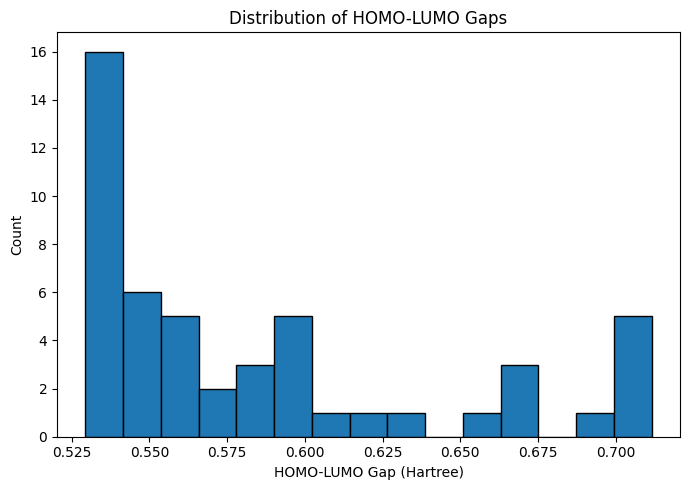

In [30]:

# =========================
# 3. HOMO-LUMO GAP DISTRIBUTION
# =========================

plt.figure(figsize=(7, 5))
plt.hist(df_clean["gap_hartree"], bins=15, edgecolor="black")
plt.xlabel("HOMO-LUMO Gap (Hartree)")
plt.ylabel("Count")
plt.title("Distribution of HOMO-LUMO Gaps")
plt.tight_layout()
plt.savefig(plot_dir / "gap_distribution.png", dpi=300)
plt.show()


## Distance vs Energy

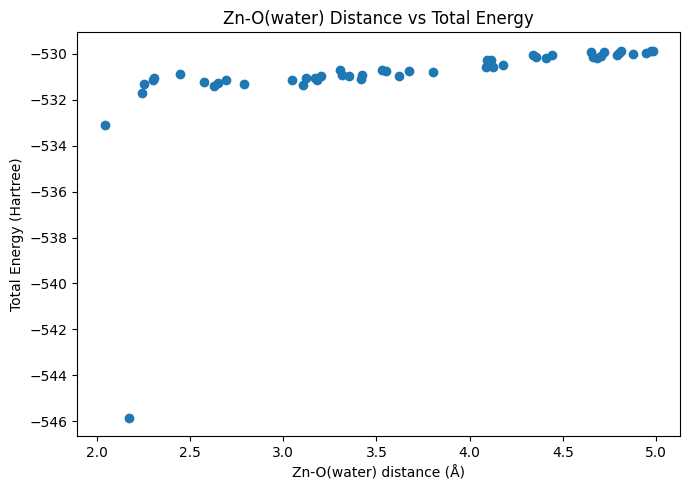

In [31]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_clean["zn_o_water_distance_A"],
    df_clean["total_energy_hartree"]
)
plt.xlabel("Zn-O(water) distance (Å)")
plt.ylabel("Total Energy (Hartree)")
plt.title("Zn-O(water) Distance vs Total Energy")
plt.tight_layout()
plt.savefig(plot_dir / "distance_vs_energy.png", dpi=300)
plt.show()

## Distance vs HOMO-LUMO Gap

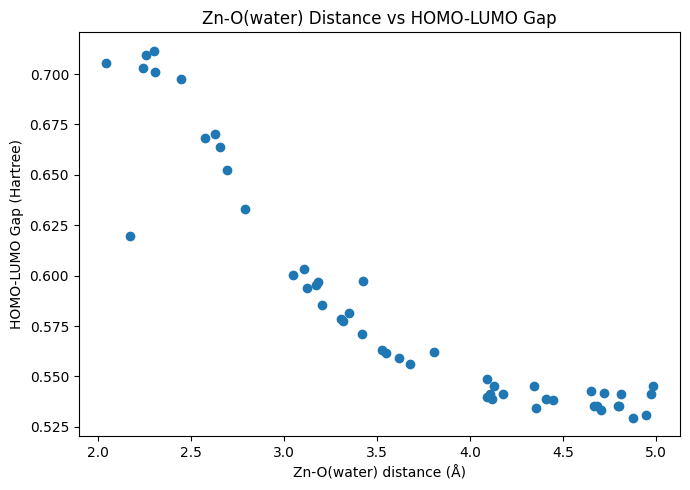

In [32]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_clean["zn_o_water_distance_A"],
    df_clean["gap_hartree"]
)
plt.xlabel("Zn-O(water) distance (Å)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Zn-O(water) Distance vs HOMO-LUMO Gap")
plt.tight_layout()
plt.savefig(plot_dir / "distance_vs_gap.png", dpi=300)
plt.show()

## Energy vs Gap

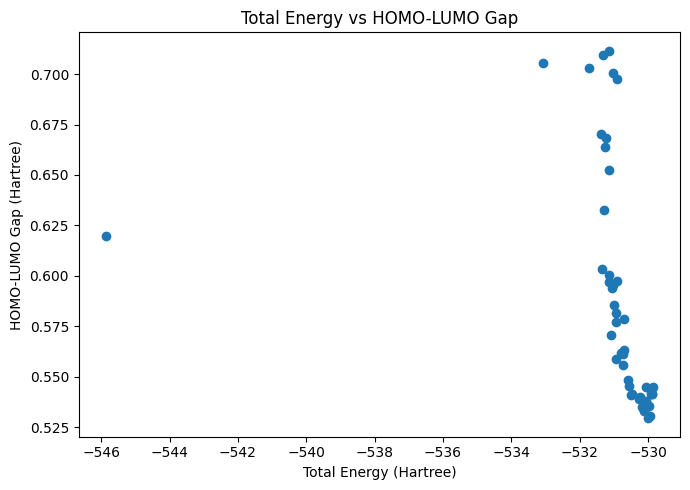

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_clean["total_energy_hartree"],
    df_clean["gap_hartree"]
)
plt.xlabel("Total Energy (Hartree)")
plt.ylabel("HOMO-LUMO Gap (Hartree)")
plt.title("Total Energy vs HOMO-LUMO Gap")
plt.tight_layout()
plt.savefig(plot_dir / "energy_vs_gap.png", dpi=300)
plt.show()


## Bootstrap Confidence intervals

In [34]:
# =========================
# 7. BOOTSTRAP CONFIDENCE INTERVALS
# =========================

def bootstrap_ci(data, n_boot=5000, ci=95):
    data = np.array(data)
    boot_means = []

    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    mean = np.mean(data)

    return mean, lower, upper, boot_means


energy_mean, energy_low, energy_high, energy_boot = bootstrap_ci(
    df_clean["total_energy_hartree"]
)

gap_mean, gap_low, gap_high, gap_boot = bootstrap_ci(
    df_clean["gap_hartree"]
)

distance_mean, distance_low, distance_high, distance_boot = bootstrap_ci(
    df_clean["zn_o_water_distance_A"]
)

print("\nBootstrap 95% Confidence Intervals")
print(f"Energy mean:   {energy_mean:.8f} Ha, CI [{energy_low:.8f}, {energy_high:.8f}]")
print(f"Gap mean:      {gap_mean:.8f} Ha, CI [{gap_low:.8f}, {gap_high:.8f}]")
print(f"Distance mean: {distance_mean:.4f} Å, CI [{distance_low:.4f}, {distance_high:.4f}]")



Bootstrap 95% Confidence Intervals
Energy mean:   -530.98741806 Ha, CI [-531.72010436, -530.56094111]
Gap mean:      0.58552545 Ha, CI [0.57035151, 0.60248751]
Distance mean: 3.6556 Å, CI [3.4135, 3.9033]


## Bootstrap histogram: Energy Mean

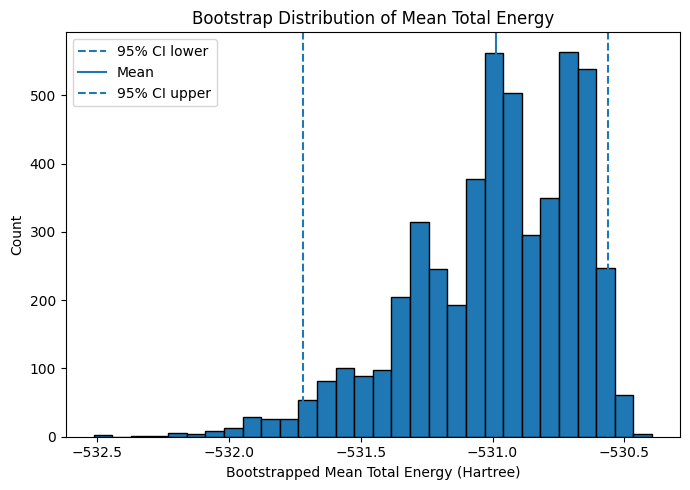

In [35]:
plt.figure(figsize=(7, 5))
plt.hist(energy_boot, bins=30, edgecolor="black")
plt.axvline(energy_low, linestyle="--", label="95% CI lower")
plt.axvline(energy_mean, linestyle="-", label="Mean")
plt.axvline(energy_high, linestyle="--", label="95% CI upper")
plt.xlabel("Bootstrapped Mean Total Energy (Hartree)")
plt.ylabel("Count")
plt.title("Bootstrap Distribution of Mean Total Energy")
plt.legend()
plt.tight_layout()
plt.savefig(plot_dir / "bootstrap_energy_mean.png", dpi=300)
plt.show()

## Bootstrap histogram: HOMO-LUMO Gap Mean

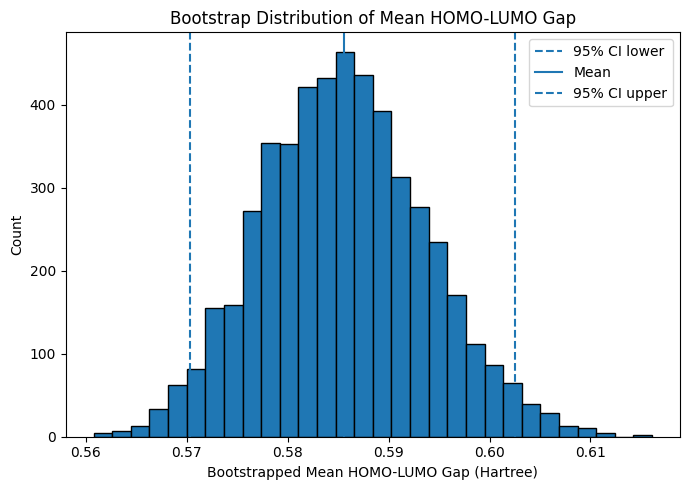


Plots saved in: water_sampling_plots


In [36]:
plt.figure(figsize=(7, 5))
plt.hist(gap_boot, bins=30, edgecolor="black")
plt.axvline(gap_low, linestyle="--", label="95% CI lower")
plt.axvline(gap_mean, linestyle="-", label="Mean")
plt.axvline(gap_high, linestyle="--", label="95% CI upper")
plt.xlabel("Bootstrapped Mean HOMO-LUMO Gap (Hartree)")
plt.ylabel("Count")
plt.title("Bootstrap Distribution of Mean HOMO-LUMO Gap")
plt.legend()
plt.tight_layout()
plt.savefig(plot_dir / "bootstrap_gap_mean.png", dpi=300)
plt.show()


print(f"\nPlots saved in: {plot_dir}")